# **Scenario 3 : Data Generation from a Probability Distribution**

As before, we train ANNs or define our own functions to calculate each variable in the DAG. However, instead of a Monte Carlo (agent based) approach, we use Causal Jazz to build a discretised probability distribution.

Install Causal Jazz once again.

In [ ]:
!git clone https://github.com/hugh-osborne/causaljazz.git

Cloning into 'causaljazz'...
remote: Enumerating objects: 1022, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 1022 (delta 10), reused 19 (delta 7), pack-reused 997 (from 3)
Receiving objects: 100% (1022/1022), 93.02 MiB | 21.49 MiB/s, done.
Resolving deltas: 100% (537/537), done.


In [ ]:
import os
os.chdir('causaljazz')
!git pull
!pip install .

Already up to date.
Processing /content/causaljazz
  Preparing metadata (setup.py) ... done
  Created wheel for causaljazz: filename=causaljazz-0.0.1-py3-none-any.whl size=20957 sha256=417d14a81705db92c2afcf717e6d1795802c53c72fbfeb05a6de08320079e88d
  Stored in directory: /tmp/pip-ephem-wheel-cache-q2ouowev/wheels/71/fa/8d/ca61e6fa79413d7d9b5420432d080e4c79100ddcdd62eee19c
Successfully built causaljazz


causaljazz/tests contains the sample data in ground.csv

In [ ]:
os.chdir('tests')


Import the usual suspects and the pmf module from causaljazz.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import csv

from causaljazz.visualiser import Visualiser
from causaljazz.cpu import pmf
from causaljazz.cpu import CausalFunction
from causaljazz.inference import TEDAG_PD
import causaljazz.data as data

from scipy.stats import norm

import tensorflow as tf
from tensorflow.keras import layers

# **Helper Functions**

In [ ]:
# Return the approximate discretised probability mass function for a normal distribution with x_mean and x_sd. The discretisation goes from x_min to x_max with res bins.
def generateGaussianNoisePmf(x_min, x_max, x_mean, x_sd, res):
    x_space = np.linspace(x_min, x_max, res)
    x_dist = [a * ((x_max-x_min)/res) for a in norm.pdf(x_space, x_mean, x_sd)]
    x_pmf = [a / sum(x_dist) for a in x_dist]
    return x_pmf

# Given a list of values representing a discretised pmf, return the cumulative list
def build_cmf(pmf):
    num_intervals = len(pmf)
    # build cmfs for sampling
    cmf = np.zeros(num_intervals)
    mass = 0.0
    for i in range(num_intervals):
        mass += pmf[i]
        cmf[i] = mass

    return cmf

# Given a list representing a discretised cmf, sample num_points points given that
# the range of the cmf is from vmin to vmax.
def sample_from_cmf(cmf, num_points, vmin, vmax):
    num_intervals = len(cmf)
    interval_width = (vmax-vmin)/num_intervals

    noise_rand = np.array([np.random.uniform() for a in range(num_points)])

    noise_sampled = np.zeros(num_points)
    for et in range(num_points):
        for i in range(num_intervals):
            if noise_rand[et] < cmf[i]:
                noise_sampled[et] = vmin + (i * interval_width) + (interval_width * np.random.uniform())
                break

    return noise_sampled

# **GenerateTrainingSets**


In [ ]:
def generateTrainingSets(data_points, input_res, output_res, output_buffer):

    # Build a histogram of the data_points, normalised so that it resembles a discretised probability mass function
    # pmf takes
    # An initial distribution (empty as we will populate using the data points),
    # An origin value for each variable (zeros)
    # The cell (bin) widths for each dimension: 1.0/input_res for all input variables then 1.0/output_res for the final dimension
    # An epsilon value below which to ignore very small probability mass values - in this case we want as accurate as possible so set to 0
    data_pmf = pmf(np.array([]), np.zeros([data_points.shape[0]]), np.concatenate([np.ones([data_points.shape[0]-1])/input_res, np.array([1.0/output_res])], axis=0), _mass_epsilon=0.0)
    data_points = np.transpose(data_points)
    data_pmf.generateInitialDistribtionFromSample(data_points)

    training_input = []
    training_output = []
    for p in data_points:
        # Find the discretised coordinates of p
        coords = data_pmf.calcCellCoordFromPoint(p)
        # Causal Jazz retrieves the conditional distribution for the given discretised coordinates
        strip = data_pmf.calcConditionalSliceFromCoords([a for a in range(len(input_res))], coords[:-1])
        # if the strip is empty, ignore it
        if len(strip.keys()) == 0:
            continue

        # Shift the distribution to the correct position in the double sized ANN output array
        t_output = np.zeros((output_res+output_buffer)*2)
        mass_sum = 0.0
        for k,v in strip.items():
            t_output[int(k[0]) + (output_res+output_buffer)] = v
            mass_sum += v

        if mass_sum != 0:
            t_output /= mass_sum
        # Add this training pair
        training_input += [p[:-1]]
        training_output += [t_output]

    return np.array(training_input), np.array(training_output)

# **TrainANN**

In [ ]:
def trainANN(model_name, generate_model, data_points, input_res, output_res, output_buffer):

    # Forst generate a model for the expected value
    x_input = tf.keras.Input(shape=(data_points.shape[0]-1,))
    z = layers.Dense(200)(x_input)
    z_out = layers.Dense(1)(z)
    model_exp = tf.keras.Model(inputs=x_input, outputs=[z_out], name=model_name)

    if generate_model:
        # Helper callback function for the ANN to stop training early if we reach a minimum loss
        callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                    patience=10,
                                                    restore_best_weights=True)
        # Train the model and save the weights in a file for quick retrieval later
        model_exp.compile(loss='mae', optimizer=tf.keras.optimizers.Adam())
        model_exp.fit(x=np.array(data_points[:-1,:].T), y=np.array(data_points[-1,:]), epochs=2000, batch_size=100, callbacks=[callback], verbose=1)
        model_exp.save_weights(model_name + '_exp.weights.h5')

    else:
        model_exp.load_weights(model_name +'_exp.weights.h5')

    def func_expected(y):
        return model_exp.predict(np.array(y), verbose=False)

    # For technical reasons, we set the full output length to 2 times the output_res + buffer.
    # Causal Jazz stores only the relative coordinates of each distribution from an origin.
    # but the ANN only returns a list of values without reference.
    # By doubling the output size, we can set the central value of the ANN output to be the origin coord
    # of the distribution and still ensure we capture everything.
    strip_length = 2*(output_res + output_buffer)

    # Define a simple ANN to estimate the discretised conditional distribution P(X2|X1) for each input point, X1
    x_input = tf.keras.Input(shape=(data_points.shape[0]-1,))
    z = layers.Dense(200)(x_input)
    z_out = layers.Dense(strip_length, activation="sigmoid")(z)
    model = tf.keras.Model(inputs=x_input, outputs=[z_out], name=model_name)
    #model.summary()

    if generate_model:
        # Calculate the difference between the output variable and the expected value
        expected_values = func_expected(data_points[:-1,:].T)
        diff = np.concatenate([np.zeros(data_points[:-1,:].shape), np.reshape(expected_values, (1,data_points.shape[1]))], axis=0)
        data_points -= diff

        # Build the training data
        training_input, training_output = generateTrainingSets(data_points, input_res, output_res, output_buffer)

        # Helper callback function for the ANN to stop training early if we reach a minimum loss
        callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                                    patience=10,
                                                    restore_best_weights=True)

        # Train the model and save the weights in a file for quick retrieval later
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam())
        model.fit(x=np.array(training_input), y=np.array(training_output), epochs=2000, batch_size=100, callbacks=[callback], verbose=1)
        model.save_weights(model_name + '.weights.h5')

    else:
        model.load_weights(model_name +'.weights.h5')

    # Build a function to take a set of points and return a matching set of estimated conditional distributions
    # This will be used by Causal Jazz to build the final joint distribution
    def func_noise(y):
        print(np.array(y).shape)
        test = model.predict(np.array(y), verbose=False)
        # rescale the output to ensure the probability sums to 1
        # this isn't guaranteed by the ANN but it should be close if its trained correctly
        test /= np.stack([np.sum(test, axis=1) for a in range(test.shape[1])]).T
        print(test.T.shape)
        return test.T

    return func_expected, func_noise

Load the original data into an ND-array structure.
The original data is made up of up to 50 sets of 1000 data points. Setting number_of_experiments higher improves the functions.

In [ ]:
csv_names = ['X1', 'X2', 'LC', 'X3', 'SF']

# Load the data into an array
ground = [] # The ground truth array
number_of_experiments = 25
with open('ground.csv') as csvfile:
    ground_reader = csv.DictReader(csvfile)
    for row in ground_reader:
        if int(row['Sim']) > number_of_experiments:
            break
        d = [float(a) for a in [row[k] for k in csv_names]]
        ground += [d]

# Normalise it otherwise training doesn't work!
max_vals = np.max(ground, axis=0)
min_vals = np.min(ground, axis=0)
ground = ((np.array(ground)-min_vals)/(max_vals-min_vals))

Set grid resolution variables and flags.

In [ ]:
generate_models = True

input_res = 10
output_res = 30
output_buffer = 5
total_output_size = 2*(output_res+output_buffer)

# **Latent Function C**

Before learning the ANN functions, let's design our function for C.<br>

*func_c* takes two inputs, X<sub>1</sub> and X<sub>2</sub>, and returns a distribution across two values, 0 and 1.

To achieve the expected path coefficients, we first define the expected value of a non-dichotomised (non-binary) C based on X<sub>1</sub> and X<sub>2</sub>.
<br><br>
E[C] <- 0.3X<sub>1</sub> + 0.3X<sub>2</sub>
<br><br>
Next, we must define the variance of C for each value of X<sub>1</sub> and X<sub>2</sub>. For simplicity we will assume that the variance is normally distributed around the expected value with a standard deviation of 1. The conditional distributions could be dependent on the inputs and considerably more complicated than a normal distribution. Note that any skew or bias in the distribution will affect the resulting covariance.<br><br>
If the latent variable is not to be processed further (for example dichotomised), the function is simple and can return a normal distribution around the expected value. However, this imparts no new information from the latent variable beyond some additional variance - which may be all that is required (enigmatic variation). In this case, though, we also wish to capture a 30/70 split between high and low risk groups. <br><br>
To get a distribution across two values, 1 and 0, we need to dichotamise the joint distribution so that 30% falls into the high-risk group (C=1). This step has to be performed on the full joint distribution of X<sub>1</sub>, X<sub>2</sub>, and C so that lower values of X<sub>1</sub> and X<sub>2</sub> are more likely to appear in the low-risk group.



In [ ]:
def func_c_exp(y):
  x1 = np.array(y)[:,0]
  x2 = np.array(y)[:,1]

  out = np.reshape((0.3*x1 + 0.3*x2), (np.array(y).shape[0],1))
  print(out.shape)
  return out

def func_c_noise(y):
  x1 = np.array(y)[:,0]
  x2 = np.array(y)[:,1]

  out = np.array([generateGaussianNoisePmf(-0.5, 0.5, 0, 0.1, total_output_size) for a in range(np.array(y).shape[0])]).T
  print(out.shape)
  return out

def func_c_sampled(y):
  x1 = y[0]
  x2 = y[1]

  exp_c = 0.3*x1 + 0.3*x2
  cont_c = np.random.normal(loc=exp_c, scale=0.1)
  return cont_c
  #if cont_c > 0.2:
  #  return 1
  #else:
  #  return 0

Learn the functions for X<sub>2</sub>, X<sub>3</sub>, and S. In this example dataset, X<sub>1</sub> is normally distributed around 0.0 with a standard deviation of 1.0.

In [ ]:
# X2 <- X1
data_points = np.stack([ground[:,0], ground[:,1]])
func_e_x2, func_x2_noise = trainANN('x2_given_x1', generate_models, data_points, [input_res], output_res, output_buffer)

# C <- X1,X2
generated_c = np.array([func_c_sampled(x) for x in ground[:,:2]])
print(np.sum(generated_c), generated_c.shape)

# X3 <- X1,X2,C
data_points = np.stack([ground[:,0], ground[:,1], generated_c, ground[:,3]])
func_e_x3, func_x3_noise = trainANN('x3_given_x1x2c', generate_models, data_points, [input_res,input_res,input_res], output_res, output_buffer)

# S <- X1,X2,C,X3
data_points = np.stack([ground[:,0], ground[:,1], generated_c, ground[:,3], ground[:,4]])
func_e_s, func_s_noise  = trainANN('s_given_x1x2cx3', generate_models, data_points, [input_res,input_res,input_res,input_res], output_res, output_buffer)

Epoch 1/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1102
Epoch 2/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0907
Epoch 3/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0908
Epoch 4/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0911
Epoch 5/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0909
Epoch 6/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0911
Epoch 7/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0909
Epoch 8/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0909
Epoch 9/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0907
Epoch 10/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0908
Epoch 11/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0909
Epoch 12/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0908
Epoch 1/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0345
Epoch 2/2000
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.0683e-04
Epoch 3/2000
250/250 ━━━━━━

# **Causal Jazz Simulation**

In [ ]:
# Define the Causal Jazz transition function
# It takes the name of the python function, the number of inputs, and a flag to say this is a function
# that returns a discretised distribution (as opposed to a single value)
trans_x2_e = CausalFunction(func_e_x2, 1)
trans_x2_noise = CausalFunction(func_x2_noise, 1, transition_function=True)
trans_lc_e = CausalFunction(func_c_exp, 2)
trans_lc_noise = CausalFunction(func_c_noise, 2, transition_function=True)
trans_x3_e = CausalFunction(func_e_x3, 3)
trans_x3_noise = CausalFunction(func_x3_noise, 3, transition_function=True)
trans_s_e  = CausalFunction(func_e_s, 4)
trans_s_noise  = CausalFunction(func_s_noise, 4, transition_function=True)

# Make a function to sum things
# Helper function to sum the inputs (in this case, sum the expected value and the noise)
def func_sum(y):
  out = np.reshape(np.sum(y, axis=-1), (np.array(y).shape[0],1))
  print(out.shape)
  return out

trans_sum = CausalFunction(func_sum, 2)

# Template distribution space for each variable
# The templates must have the same cell widths as the pmfs used to train the functions
x2_template = pmf(np.array([]), np.array([0.0]), np.array([1.0 / output_res]), 0.000001) # The minimum mass should obviously be 0
lc_template = pmf(np.array([]), np.array([0.0]), np.array([1.0 / output_res]), 0.000001)
x3_template = pmf(np.array([]), np.array([0.0]), np.array([1.0 / output_res]), 0.000001)
s_template  = pmf(np.array([]), np.array([0.0]), np.array([1.0 / output_res]), 0.000001)

# Define the variable names for each function in TEDAG
tedag_func_x2_e = TEDAG_PD.FUNCTION(['X1'], 'X2E', 0, trans_x2_e, x2_template)
tedag_func_x2_noise = TEDAG_PD.FUNCTION(['X1'], 'X2N', 0, trans_x2_noise, x2_template)
tedag_func_x2 = TEDAG_PD.FUNCTION(['X2E', 'X2N'], 'X2', 0, trans_sum, x2_template)
tedag_func_lc_e = TEDAG_PD.FUNCTION(['X1', 'X2'], 'LCE', 0, trans_lc_e, lc_template)
tedag_func_lc_noise = TEDAG_PD.FUNCTION(['X1', 'X2'], 'LCN', 0, trans_lc_noise, lc_template)
tedag_func_lc = TEDAG_PD.FUNCTION(['LCE', 'LCN'], 'LC', 0, trans_sum, lc_template)
tedag_func_x3_e = TEDAG_PD.FUNCTION(['X1', 'X2', 'LC'], 'X3E', 0, trans_x3_e, x3_template)
tedag_func_x3_noise = TEDAG_PD.FUNCTION(['X1', 'X2', 'LC'], 'X3N', 0, trans_x3_noise, x3_template)
tedag_func_x3 = TEDAG_PD.FUNCTION(['X3E', 'X3N'], 'X3', 0, trans_sum, x3_template)
tedag_func_s_e  = TEDAG_PD.FUNCTION(['X1', 'X2', 'LC', 'X3'], 'SE', 0, trans_s_e, s_template)
tedag_func_s_noise  = TEDAG_PD.FUNCTION(['X1', 'X2', 'LC', 'X3'], 'SN', 0, trans_s_noise, s_template)
tedag_func_s = TEDAG_PD.FUNCTION(['SE', 'SN'], 'S', 0, trans_sum, s_template)

# Initialise the TEDAG
tedag = TEDAG_PD(1, [tedag_func_x2_e,tedag_func_x2_noise,tedag_func_lc_e,tedag_func_lc_noise,tedag_func_x2,tedag_func_lc,tedag_func_x3_e,tedag_func_x3_noise,tedag_func_x3,tedag_func_s_e,tedag_func_s_noise,tedag_func_s], observables=['X1', 'X2', 'LC', 'X3', 'S'], verbose=True)

# Add a single intervention to set X1
x1 = generateGaussianNoisePmf(-3.0,3.0,0.0,1.0, output_res)
x1 /= max_vals[0]
x1_pmf = pmf(np.array(x1), np.array([0.0]), np.array([1.0/output_res]), 0.000001)
tedag.addIntervention(['X1'], 0, x1_pmf)

# Forward calculate the distributions
while tedag.findNextFunctionAndApply(0):
    continue

In findNextFunctionAndApply, found function X2E at iteration 0
Required input variables are: ['X10']
Input pmf is ['X10']
Output pmf has variables ['X10', 'X2E0']
Variables in the input pmf required by the function are [0]
Mapping input var names to output var names...  ['X10'] ['X10', 'X2E0'] {0: 0}
Current Nodes: ['X10', 'X2E0']
Node X2E0 already in current nodes. Skipping.
In findNextFunctionAndApply, found function X2N at iteration 0
Required input variables are: ['X10']
Input pmf is ['X10', 'X2E0']
Output pmf has variables ['X10', 'X2E0', 'X2N0']
Variables in the input pmf required by the function are [0]
Mapping input var names to output var names...  ['X10', 'X2E0'] ['X10', 'X2E0', 'X2N0'] {0: 0, 1: 1}
(30, 1)
(70, 30)
Current Nodes: ['X10', 'X2E0', 'X2N0']
Node X2E0 already in current nodes. Skipping.
Node X2N0 already in current nodes. Skipping.
Node LCE0 is missing required args. ['X20'] Skipping.
Node LCN0 is missing required args. ['X20'] Skipping.
In findNextFunctionAndApp

Let's plot the points and compare to the original data.

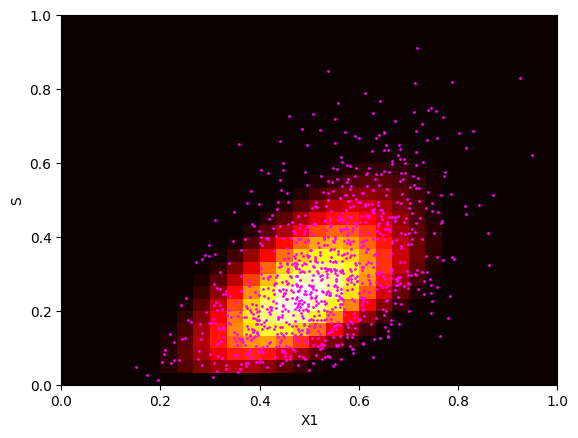

In [ ]:
space = [0.0, 1.0, 0.0, 1.0]
var_names = ['X1', 'S']

fig = plt.figure(1, dpi=100)

tedag_pmf = tedag.getPmfForIteration(var_names, 0)
if tedag_pmf is not None:
    node_indices = [[n.key for n in tedag_pmf.nodes].index(a+str(0)) for a in var_names]
    coords, centroids, vals = tedag_pmf.pmf.calcMarginal(node_indices)

    vals = np.array(vals)
    coords = np.array(coords)
    grid = np.zeros((output_res,output_res))
    for c in range(len(vals)):
        ws = [tedag_pmf.pmf.cell_widths[node_indices[0]],tedag_pmf.pmf.cell_widths[node_indices[1]]]
        os = [tedag_pmf.pmf.origin[node_indices[0]], tedag_pmf.pmf.origin[node_indices[1]]]
        cs = [coords[c][0]+(int((os[0]-space[0])/ws[0])), coords[c][1]+(int((os[1]-space[2])/ws[1]))]
        cs = [c if c < output_res else output_res-1 for c in cs]
        cs = [c if c >= 0 else 0 for c in cs]
        grid[int(cs[0]),int(cs[1])] = vals[c]
    grid = np.transpose(grid)

    plt.xlim([space[0],space[1]])
    plt.xlabel(var_names[0])
    plt.ylabel(var_names[1])
    plt.ylim([space[2],space[3]])
    plt.imshow(grid, cmap='hot', origin='lower', extent=(space[0],space[1],space[2],space[3]), aspect='auto')

    plt.scatter(ground[:1000,0],ground[:1000,4],s=1.0,color='#FF00FF')
    #plt.scatter(ground[:1000,0],ground[:1000,1],s=0.2)
plt.show(block=False)
plt.close()